In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '2'
os.environ['MKL_NUM_THREADS'] = '2'
os.environ['OPENBLAS_NUM_THREADS'] = '2'
os.environ['NUMEXPR_NUM_THREADS'] = '2'
os.environ['VECLIB_MAXIMUM_THREADS'] = '2'

print("? Thread limits set to 2 in this notebook")

? Thread limits set to 2 in this notebook


In [1]:
# ==================== CELL 1: GIN Setup, training, and attack utilities ====================
import os
import random
import ast
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------- Load dataset ----------
CSV_PATH = "all_circuits_features.csv"   # your CSV
df = pd.read_csv(CSV_PATH)

print("\nDataset head:")
print(df.head())

# ---------- Label encode gate_type ----------
label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])

# ---------- Feature columns ----------
feature_columns = [
    "fan_in", "fan_out", "dist_to_output", "is_primary_input", "is_primary_output",
    "is_internal", "is_key_gate", "degree_centrality", "betweenness_centrality",
    "closeness_centrality", "clustering_coefficient", "avg_fan_in_neighbors", "avg_fan_out_neighbors"
]

df = df.dropna(subset=feature_columns).reset_index(drop=True)
df[feature_columns] = df[feature_columns].astype(float)

# ---------- Standardize ----------
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

# ---------- Build nodes & edges ----------
nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

edges = []
for idx, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    potential_sources = df[df["fan_out"] > 0]["node"].tolist()
    sources = potential_sources[:int(row["fan_in"])] if int(row["fan_in"]) > 0 else []
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

print(f"\nExtracted {len(edges)} edges (approximate fan-in construction).")
if len(edges) == 0:
    raise ValueError("No edges found! Check fan_in/fan_out in CSV.")

src_nodes, dst_nodes = zip(*edges)
src_tensor = torch.tensor(src_nodes, dtype=torch.int64)
dst_tensor = torch.tensor(dst_nodes, dtype=torch.int64)

valid_edges = (src_tensor >= 0) & (dst_tensor >= 0) & (src_tensor < len(nodes)) & (dst_tensor < len(nodes))
src_tensor = src_tensor[valid_edges]
dst_tensor = dst_tensor[valid_edges]

# ---------- DGL graph ----------
graph = dgl.graph((src_tensor, dst_tensor), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)

graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)

# ---------- Train-test split ----------
num_nodes = graph.num_nodes()
indices = np.arange(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# ---------- Define GIN ----------
class GIN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GIN, self).__init__()
        # MLPs used inside GINConv layers
        mlp1 = nn.Sequential(
            nn.Linear(in_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, hidden_feats)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )
        self.conv1 = dglnn.GINConv(mlp1, learn_eps=True)
        self.conv2 = dglnn.GINConv(mlp2, learn_eps=True)

    def forward(self, g, inputs):
        x = self.conv1(g, inputs)
        x = torch.relu(x)
        x = self.conv2(g, x)
        return x

in_feats = len(feature_columns)
hidden_feats = 32
out_feats = len(label_encoder.classes_)
model = GIN(in_feats, hidden_feats, out_feats)

# ---------- Move to device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
graph = graph.to(device)
graph.ndata['features'] = graph.ndata['features'].to(device)
graph.ndata['labels'] = graph.ndata['labels'].to(device)
train_mask = train_mask.to(device)
test_mask = test_mask.to(device)

# ---------- Train ----------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

epochs = 50
for epoch in range(epochs):
    model.train()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[train_mask], graph.ndata['labels'][train_mask])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

# ---------- Evaluate ----------
model.eval()
with torch.no_grad():
    logits_all = model(graph, graph.ndata['features'])
    test_pred = logits_all[test_mask].argmax(dim=1)
    test_acc = (test_pred == graph.ndata['labels'][test_mask]).float().mean().item()
    train_pred = logits_all[train_mask].argmax(dim=1)
    train_acc = (train_pred == graph.ndata['labels'][train_mask]).float().mean().item()

print(f"\nTest Accuracy: {test_acc*100:.2f}%, Train Accuracy: {train_acc*100:.2f}%")

# ---------- Attack utilities ----------
EPS = 1e-8

def compute_true_grads(model, graph, target_idx):
    model.zero_grad()
    logits = model(graph, graph.ndata['features'])
    loss = loss_fn(logits[target_idx:target_idx+1], graph.ndata['labels'][target_idx:target_idx+1])
    grads = torch.autograd.grad(loss, tuple(model.parameters()), allow_unused=True)
    grads_filled = []
    for p, g in zip(model.parameters(), grads):
        grads_filled.append(torch.zeros_like(p).detach() if g is None else g.detach().clone())
    return grads_filled

def grad_inversion_with_target_grads(model, graph, target_idx, grads_target_mod,
                                     steps=300, lr=0.05, l2_reg=1e-3,
                                     normalize_paramwise=True, clamp_range=5.0, early_stop_patience=40,
                                     verbose=False):
    model.eval()
    X_orig = graph.ndata['features'].detach()
    x_true = X_orig[target_idx:target_idx+1].detach().to(device)
    y_true = graph.ndata['labels'][target_idx:target_idx+1].detach().to(device)

    x_rec = torch.randn_like(x_true, requires_grad=True, device=device)
    optimizer_rec = optim.Adam([x_rec], lr=lr)
    best_loss, best_x, stale = float('inf'), None, 0

    for it in range(steps):
        optimizer_rec.zero_grad()
        X_mod = X_orig.clone()
        X_mod[target_idx:target_idx+1] = x_rec
        logits_mod = model(graph, X_mod)
        loss_mod = loss_fn(logits_mod[target_idx:target_idx+1], y_true)
        grads_rec = torch.autograd.grad(loss_mod, tuple(model.parameters()), create_graph=True, allow_unused=True)

        total = torch.tensor(0.0, device=device)
        for gr_rec, gr_tgt in zip(grads_rec, grads_target_mod):
            if gr_rec is None: continue
            gt = gr_tgt.to(device)
            total = total + ((gr_rec - gt).pow(2).sum() / (float(gt.numel()) + EPS) if normalize_paramwise else (gr_rec - gt).pow(2).sum())
        reg = l2_reg * torch.norm(x_rec, p=2)
        objective = total + reg
        objective.backward()
        optimizer_rec.step()

        with torch.no_grad(): x_rec.clamp_(-clamp_range, clamp_range)
        cur_loss = objective.item()
        if cur_loss < best_loss - 1e-7:
            best_loss, best_x, stale = cur_loss, x_rec.detach().clone(), 0
        else:
            stale += 1
            if stale >= early_stop_patience: break

    if best_x is None: best_x = x_rec.detach().clone()
    abs_l2 = torch.norm(best_x - x_true).item()
    rel_l2 = abs_l2 / (torch.norm(x_true).item() + EPS)
    cos_sim = (torch.nn.functional.cosine_similarity(best_x.view(-1), x_true.view(-1), dim=0).item())

    return best_x.cpu(), {"abs_l2": abs_l2, "rel_l2": rel_l2, "cos_sim": cos_sim}

# ---------- Sample nodes per class ----------
unique_labels = torch.unique(graph.ndata['labels']).cpu().numpy()
sampled_nodes_per_label = {}
for lbl in unique_labels:
    train_indices = torch.where(train_mask & (graph.ndata['labels'] == int(lbl)))[0].cpu().numpy().tolist()
    k = min(20, len(train_indices))
    sampled = random.sample(train_indices, k) if len(train_indices) > 0 else []
    sampled_nodes_per_label[int(lbl)] = sampled
    pretty_name = label_encoder.inverse_transform([int(lbl)])[0]
    print(f"Label {int(lbl)} ({pretty_name}): sampling {len(sampled)} nodes")

np.save("sampled_nodes_per_label.npy", sampled_nodes_per_label)
print("\nSaved sampled nodes mapping to 'sampled_nodes_per_label.npy'.")

print("\nCELL 1 (GIN) complete. Available variables:")
print(" - graph, model, train_mask, test_mask, label_encoder, sampled_nodes_per_label")
print(" - compute_true_grads(model, graph, idx)")
print(" - grad_inversion_with_target_grads(model, graph, idx, grads_target_mod, ...)")



Dataset head:
  circuit_name node gate_type  fan_in  fan_out  \
0      adder.v   g1       not       1        1   
1      adder.v   g2       and       2        1   
2      adder.v   g3       not       1        1   
3      adder.v   g4       and       2        1   
4      adder.v   g5        or       2        1   

                                      depth  dist_to_output  is_primary_input  \
0  {'g1': 0, 'g2': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
1           {'g2': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
2  {'g3': 0, 'g4': 1, 'g5': 2, '\\f[0]': 3}               3                 0   
3           {'g4': 0, 'g5': 1, '\\f[0]': 2}               2                 0   
4                    {'g5': 0, '\\f[0]': 1}               1                 0   

   is_primary_output  is_internal  is_key_gate key_dependency  \
0                  0            1            0            NaN   
1                  0            1            0            NaN   
2 


GCN MODEL PERFORMANCE METRICS
Training Accuracy: 0.9344
Test Accuracy: 0.9331

Confusion Matrix:


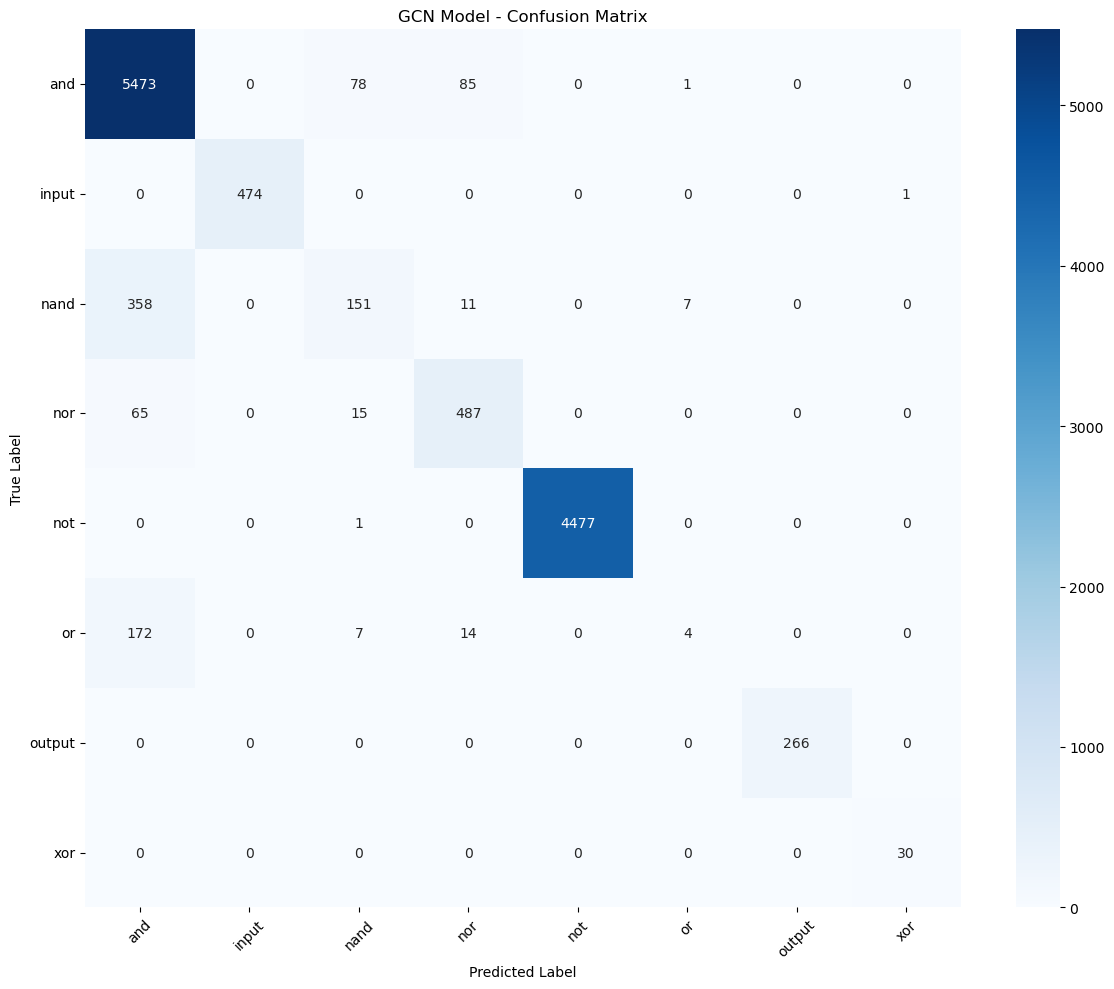


Classification Report:
              precision    recall  f1-score   support

         and       0.90      0.97      0.94      5637
       input       1.00      1.00      1.00       475
        nand       0.60      0.29      0.39       527
         nor       0.82      0.86      0.84       567
         not       1.00      1.00      1.00      4478
          or       0.33      0.02      0.04       197
      output       1.00      1.00      1.00       266
         xor       0.97      1.00      0.98        30

    accuracy                           0.93     12177
   macro avg       0.83      0.77      0.77     12177
weighted avg       0.92      0.93      0.92     12177


Overall Metrics:
Precision: 0.9178
Recall: 0.9331
F1-Score: 0.9202

Per-class Metrics:
Class and: Precision=0.9019, Recall=0.9709, F1=0.9352
Class input: Precision=1.0000, Recall=0.9979, F1=0.9989
Class nand: Precision=0.5992, Recall=0.2865, F1=0.3877
Class nor: Precision=0.8157, Recall=0.8589, F1=0.8368
Class not: Precisi

In [2]:
# Add these imports if not already present
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns

# -----------------------------------
# Evaluate GCN Model Performance
# -----------------------------------

print("\n" + "="*50)
print("GCN MODEL PERFORMANCE METRICS")
print("="*50)

# Get predictions
model.eval()
with torch.no_grad():
    # Training predictions
    train_logits = model(graph, graph.ndata['features'])
    train_pred = train_logits[train_mask].argmax(dim=1)
    train_labels = graph.ndata['labels'][train_mask]
    train_accuracy = (train_pred == train_labels).float().mean().item()
    
    # Test predictions
    test_logits = model(graph, graph.ndata['features'])
    test_pred = test_logits[test_mask].argmax(dim=1)
    test_labels = graph.ndata['labels'][test_mask]
    test_accuracy = (test_pred == test_labels).float().mean().item()

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Convert to CPU numpy for sklearn metrics
test_pred_np = test_pred.cpu().numpy()
test_labels_np = test_labels.cpu().numpy()
train_pred_np = train_pred.cpu().numpy()
train_labels_np = train_labels.cpu().numpy()

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels_np, test_pred_np)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('GCN Model - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels_np, test_pred_np, 
                          target_names=label_encoder.classes_))

# Overall Precision, Recall, F1-Score
overall_precision = precision_score(test_labels_np, test_pred_np, average='weighted')
overall_recall = recall_score(test_labels_np, test_pred_np, average='weighted')
overall_f1 = f1_score(test_labels_np, test_pred_np, average='weighted')

print("\nOverall Metrics:")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1-Score: {overall_f1:.4f}")

# Per-class metrics
print("\nPer-class Metrics:")
precision_per_class = precision_score(test_labels_np, test_pred_np, average=None)
recall_per_class = recall_score(test_labels_np, test_pred_np, average=None)
f1_per_class = f1_score(test_labels_np, test_pred_np, average=None)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"Class {class_name}: Precision={precision_per_class[i]:.4f}, "
          f"Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")

# Additional: Training vs Test accuracy comparison
print(f"\nAccuracy Comparison:")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Gap: {abs(train_accuracy - test_accuracy)*100:.2f}%")

# Class distribution in test set
unique, counts = np.unique(test_labels_np, return_counts=True)
print(f"\nClass distribution in test set:")
for i, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([i])[0]
    print(f"  {class_name}: {count} samples ({count/len(test_labels_np)*100:.1f}%)")

In [3]:
# ==================== CELL 2: No Defense (Baseline for GIN) ====================
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# ---------- Parameters ----------
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

# ---------- Load sampled nodes ----------
sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()

rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total baseline attacks to run:", total)

# ---------- Loop over all sampled nodes ----------
for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"NoDef (GIN) label {label_name}"):
        # compute true grads for the target node
        grads_true = compute_true_grads(model, graph, target_idx)

        # observed grads = true grads (no defense)
        grads_obs = [g.clone() for g in grads_true]

        # run gradient inversion
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )

        rows.append({
            "defense": "None",
            "defense_key": "none",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

# ---------- Save results ----------
df_none = pd.DataFrame(rows)
df_none.to_csv("results_none_gin.csv", index=False)
print(f"Saved results_none_gin.csv (rows: {len(df_none)})")

# ---------- Per-class summary ----------
print("\nBaseline summary (GIN)  mean ± std:")
print(df_none.groupby("label_name")[["abs_l2", "rel_l2", "cos_sim"]].agg(["mean", "std", "count"]))


Total baseline attacks to run: 160


NoDef (GIN) label xor: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [16:58<00:00, 50.92s/it]

Saved results_none_gin.csv (rows: 160)

Baseline summary (GIN)  mean ± std:
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.503826  1.640446    20  1.769794  1.063662    20  0.103856   
input        6.874740  0.662535    20  1.002365  0.095917    20  0.240714   
nand         3.713094  2.065138    20  1.742572  0.907119    20  0.286493   
nor          4.854386  1.533023    20  1.293378  0.465471    20  0.086878   
not          2.906643  1.541908    20  1.637044  0.831928    20  0.234909   
or           3.669004  1.450417    20  1.858653  0.828438    20  0.099608   
output       8.168988  1.161647    20  0.972946  0.138164    20  0.224072   
xor         22.812503  0.987354    20  0.971747  0.031591    20  0.268626   

                            
                 std count  
label_name        

In [4]:
# ==================== CELL 3: Gradient Clipping + Perturbation (GIN) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

clip_value = 1.0
perturb_std = 0.05

recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []
total = sum(len(v) for v in sampled_nodes_per_label.values())
print("Total grad-clip attacks to run:", total)

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"GradClip (GIN) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = []
        for g in grads_true:
            g_clipped = torch.clamp(g, -clip_value, clip_value)
            g_noisy = g_clipped + torch.randn_like(g_clipped) * perturb_std
            grads_obs.append(g_noisy)
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Gradient Clipping + Perturbation",
            "defense_key": "clip_perturb",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_clip = pd.DataFrame(rows)
df_clip.to_csv("results_gin_gradclip_perturb.csv", index=False)
print(f"Saved results_gin_gradclip_perturb.csv (rows: {len(df_clip)})")
print("\nGradClip summary (mean ± std):")
print(df_clip.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Total grad-clip attacks to run: 160


GradClip (GIN) label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [16:52<00:00, 50.62s/it]

Saved results_gin_gradclip_perturb.csv (rows: 160)

GradClip summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.679172  1.392535    20  1.923186  0.961108    20  0.127625   
input        6.512984  0.904438    20  0.949550  0.131015    20  0.357185   
nand         4.290808  1.850560    20  2.124784  0.872439    20  0.094940   
nor          5.152683  1.314706    20  1.361070  0.437550    20  0.027407   
not          3.467094  1.249567    20  2.078128  0.981129    20  0.130843   
or           4.185825  1.520879    20  2.109949  0.913103    20 -0.068251   
output       8.088015  0.855246    20  0.961938  0.084392    20  0.296549   
xor         22.599734  1.164676    20  0.962473  0.036216    20  0.320257   

                            
                 std count  
label_name 

In [5]:
# ==================== CELL 4: Differential Privacy (GIN) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

dp_sigma = 0.1
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"DP (GIN) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + torch.randn_like(g) * dp_sigma for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Differential Privacy",
            "defense_key": "dp",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_dp = pd.DataFrame(rows)
df_dp.to_csv("results_gin_dp.csv", index=False)
print(f"Saved results_gin_dp.csv (rows: {len(df_dp)})")
print("\nDP summary (mean ± std):")
print(df_dp.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


DP (GIN) label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [17:29<00:00, 52.50s/it]

Saved results_gin_dp.csv (rows: 160)

DP summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.719418  1.109542    20  1.966004  0.855675    20  0.074013   
input        6.894218  0.886578    20  1.005157  0.128762    20  0.237213   
nand         3.905540  1.254927    20  2.035565  0.996389    20  0.164087   
nor          4.516178  1.198523    20  1.200198  0.451456    20  0.259615   
not          3.276419  1.289780    20  1.898121  0.811837    20  0.070012   
or           3.478486  0.943378    20  1.834748  0.700810    20  0.165452   
output       7.689277  0.955311    20  0.914430  0.099823    20  0.398593   
xor         22.715600  1.318301    20  0.967216  0.039072    20  0.317120   

                            
                 std count  
label_name                  
an

In [6]:
# ==================== CELL 5: Secure Aggregation (GIN) ====================
import numpy as np, pandas as pd, torch, random
from tqdm import tqdm

group_size = 5
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

all_labels = graph.ndata['labels'].cpu().numpy()
train_indices = torch.where(train_mask)[0].cpu().numpy()
label_to_trainlist = {int(lbl): np.intersect1d(np.where(all_labels==lbl)[0], train_indices).tolist()
                      for lbl in np.unique(all_labels)}

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"SecAgg (GIN) label {label_name}"):
        pool = label_to_trainlist.get(int(lbl), [])
        if len(pool) == 0:
            grads_obs = compute_true_grads(model, graph, target_idx)
        else:
            members = [target_idx]
            others = [i for i in pool if i != target_idx]
            k = min(len(others), group_size-1)
            if k > 0: members += random.sample(others, k)
            agg = None
            for m in members:
                g_m = compute_true_grads(model, graph, m)
                agg = [t.clone() for t in g_m] if agg is None else [a + b for a,b in zip(agg, g_m)]
            grads_obs = [a / float(len(members)) for a in agg]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Secure Aggregation",
            "defense_key": "secure_agg",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_secure = pd.DataFrame(rows)
df_secure.to_csv("results_gin_secureagg.csv", index=False)
print(f"Saved results_gin_secureagg.csv (rows: {len(df_secure)})")
print("\nSecureAgg summary (mean ± std):")
print(df_secure.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


SecAgg (GIN) label xor: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [18:00<00:00, 54.02s/it]

Saved results_gin_secureagg.csv (rows: 160)

SecureAgg summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.431047  1.461483    20  1.833926  1.043093    20  0.183013   
input        6.639709  0.885170    20  0.968333  0.130120    20  0.292487   
nand         4.106480  1.892559    20  2.021564  0.922432    20  0.085082   
nor          5.114277  1.371150    20  1.357907  0.478155    20  0.104913   
not          3.271642  1.207192    20  1.985053  0.992269    20  0.196487   
or           3.671906  1.444311    20  1.847120  0.801057    20  0.206634   
output       8.405146  0.772340    20  1.001973  0.101037    20  0.184369   
xor         22.783293  0.910859    20  0.970754  0.035516    20  0.275003   

                            
                 std count  
label_name       

In [7]:
# ==================== CELL 6: Model Quantization (GIN) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

quant_factor = 100.0
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"Quant (GIN) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [torch.round(g * quant_factor) / quant_factor for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Model Quantization",
            "defense_key": "quant",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_quant = pd.DataFrame(rows)
df_quant.to_csv("results_gin_quant.csv", index=False)
print(f"Saved results_gin_quant.csv (rows: {len(df_quant)})")
print("\nQuant summary (mean ± std):")
print(df_quant.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


Quant (GIN) label xor: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [15:08<00:00, 45.40s/it]

Saved results_gin_quant.csv (rows: 160)

Quant summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.931888  1.634484    20  1.385661  0.658904    20  0.228617   
input        7.004375  0.879659    20  1.021159  0.126723    20  0.197161   
nand         4.179524  1.638678    20  2.032663  0.735369    20  0.060939   
nor          4.548060  1.176751    20  1.234831  0.529210    20  0.246962   
not          3.540512  0.853190    20  2.143369  0.803732    20  0.137760   
or           3.731982  1.142286    20  1.946100  0.914308    20  0.046571   
output       8.250910  1.207629    20  0.983464  0.145956    20  0.234964   
xor         22.775911  1.087186    20  0.970203  0.037110    20  0.270143   

                            
                 std count  
label_name               

In [8]:
# ==================== CELL 7: Adversarial Training style perturbation (GIN) ====================
import numpy as np, pandas as pd, torch
from tqdm import tqdm

perturb_eps = 0.02
recon_steps = 200
recon_lr = 0.02
l2_reg = 0.01
clamp_range = 5.0
normalize_paramwise = True
verbose_attack = False

sampled_nodes_per_label = np.load("sampled_nodes_per_label.npy", allow_pickle=True).item()
rows = []

for lbl, node_list in sampled_nodes_per_label.items():
    label_name = label_encoder.inverse_transform([lbl])[0]
    for target_idx in tqdm(node_list, desc=f"AdvTrain (GIN) label {label_name}"):
        grads_true = compute_true_grads(model, graph, target_idx)
        grads_obs = [g + perturb_eps * torch.sign(torch.randn_like(g)) for g in grads_true]
        x_rec, metrics = grad_inversion_with_target_grads(
            model, graph, target_idx, grads_obs,
            steps=recon_steps, lr=recon_lr, l2_reg=l2_reg,
            normalize_paramwise=normalize_paramwise, clamp_range=clamp_range,
            verbose=verbose_attack
        )
        rows.append({
            "defense": "Adversarial Training",
            "defense_key": "adv_train",
            "label": int(lbl),
            "label_name": label_name,
            "node_idx": int(target_idx),
            "abs_l2": metrics["abs_l2"],
            "rel_l2": metrics["rel_l2"],
            "cos_sim": metrics["cos_sim"]
        })

df_advtrain = pd.DataFrame(rows)
df_advtrain.to_csv("results_gin_advtrain.csv", index=False)
print(f"Saved results_gin_advtrain.csv (rows: {len(df_advtrain)})")
print("\nAdvTrain summary (mean ± std):")
print(df_advtrain.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))


AdvTrain (GIN) label xor: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [10:09<00:00, 30.47s/it]

Saved results_gin_advtrain.csv (rows: 160)

AdvTrain summary (mean ± std):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.790752  1.931872    20  1.952323  1.250289    20  0.099843   
input        6.755628  0.659068    20  0.984796  0.092981    20  0.282706   
nand         4.150034  1.868936    20  2.021230  0.909389    20  0.044049   
nor          4.879280  1.258699    20  1.295613  0.365262    20  0.121601   
not          2.923334  1.356300    20  1.752905  1.083761    20  0.281516   
or           3.266923  1.410351    20  1.650091  0.688505    20  0.187455   
output       8.412121  0.825748    20  1.002404  0.103959    20  0.170069   
xor         22.816784  1.424628    20  0.971083  0.034604    20  0.287667   

                            
                 std count  
label_name         

/tmp/ipykernel_27022/4189950744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


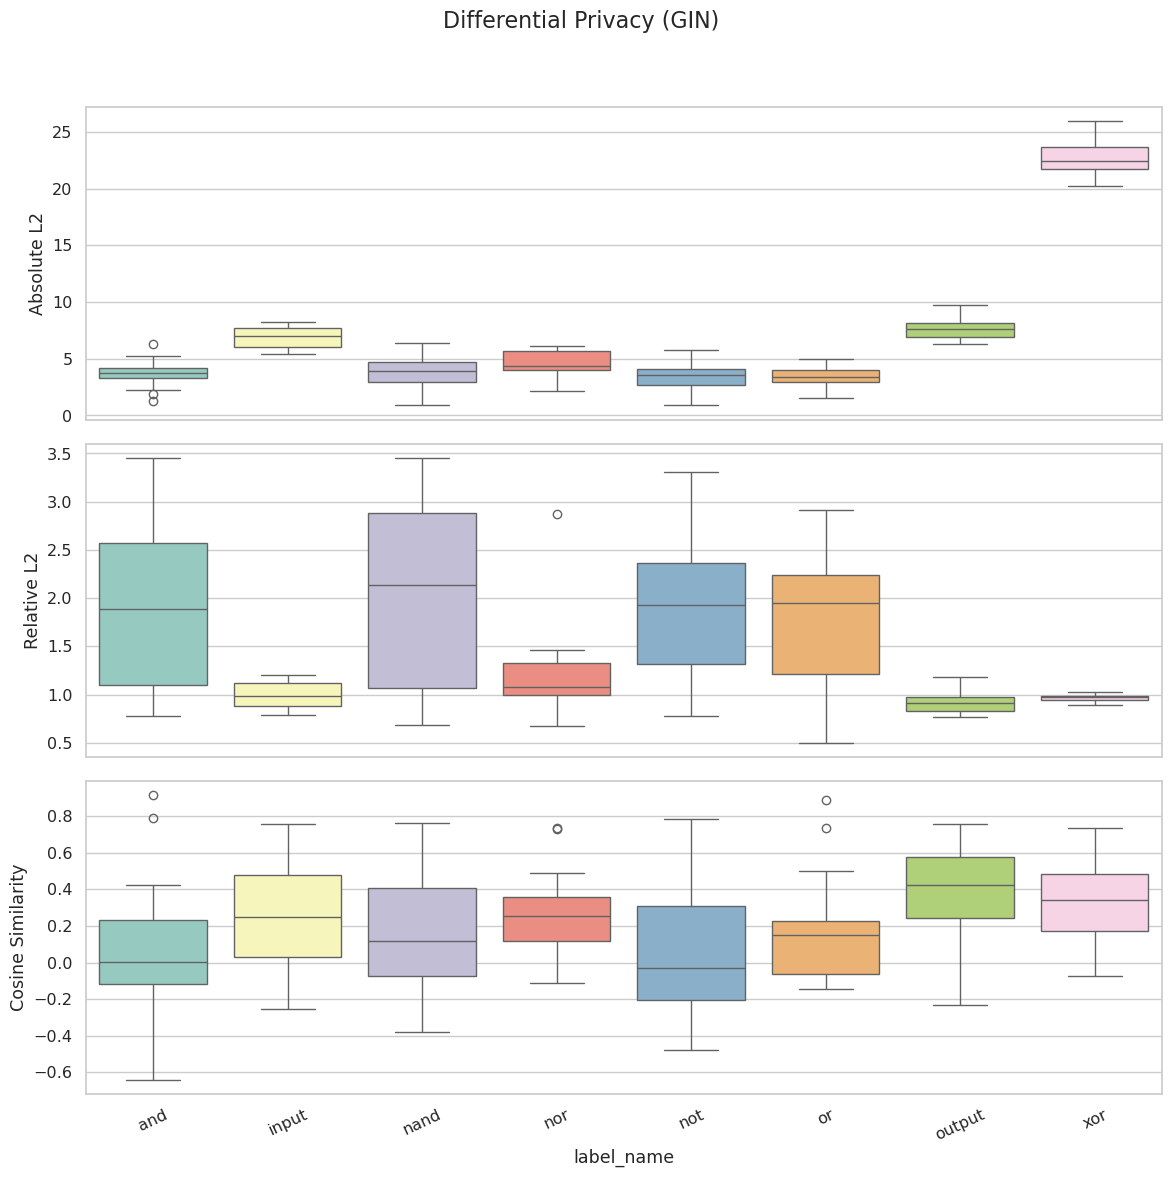


Summary for Differential Privacy (GIN):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.719418  1.109542    20  1.966004  0.855675    20  0.074013   
input        6.894218  0.886578    20  1.005157  0.128762    20  0.237213   
nand         3.905540  1.254927    20  2.035565  0.996389    20  0.164087   
nor          4.516178  1.198523    20  1.200198  0.451456    20  0.259615   
not          3.276419  1.289780    20  1.898121  0.811837    20  0.070012   
or           3.478486  0.943378    20  1.834748  0.700810    20  0.165452   
output       7.689277  0.955311    20  0.914430  0.099823    20  0.398593   
xor         22.715600  1.318301    20  0.967216  0.039072    20  0.317120   

                            
                 std count  
label_name                  
and         0.365111    

/tmp/ipykernel_27022/4189950744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


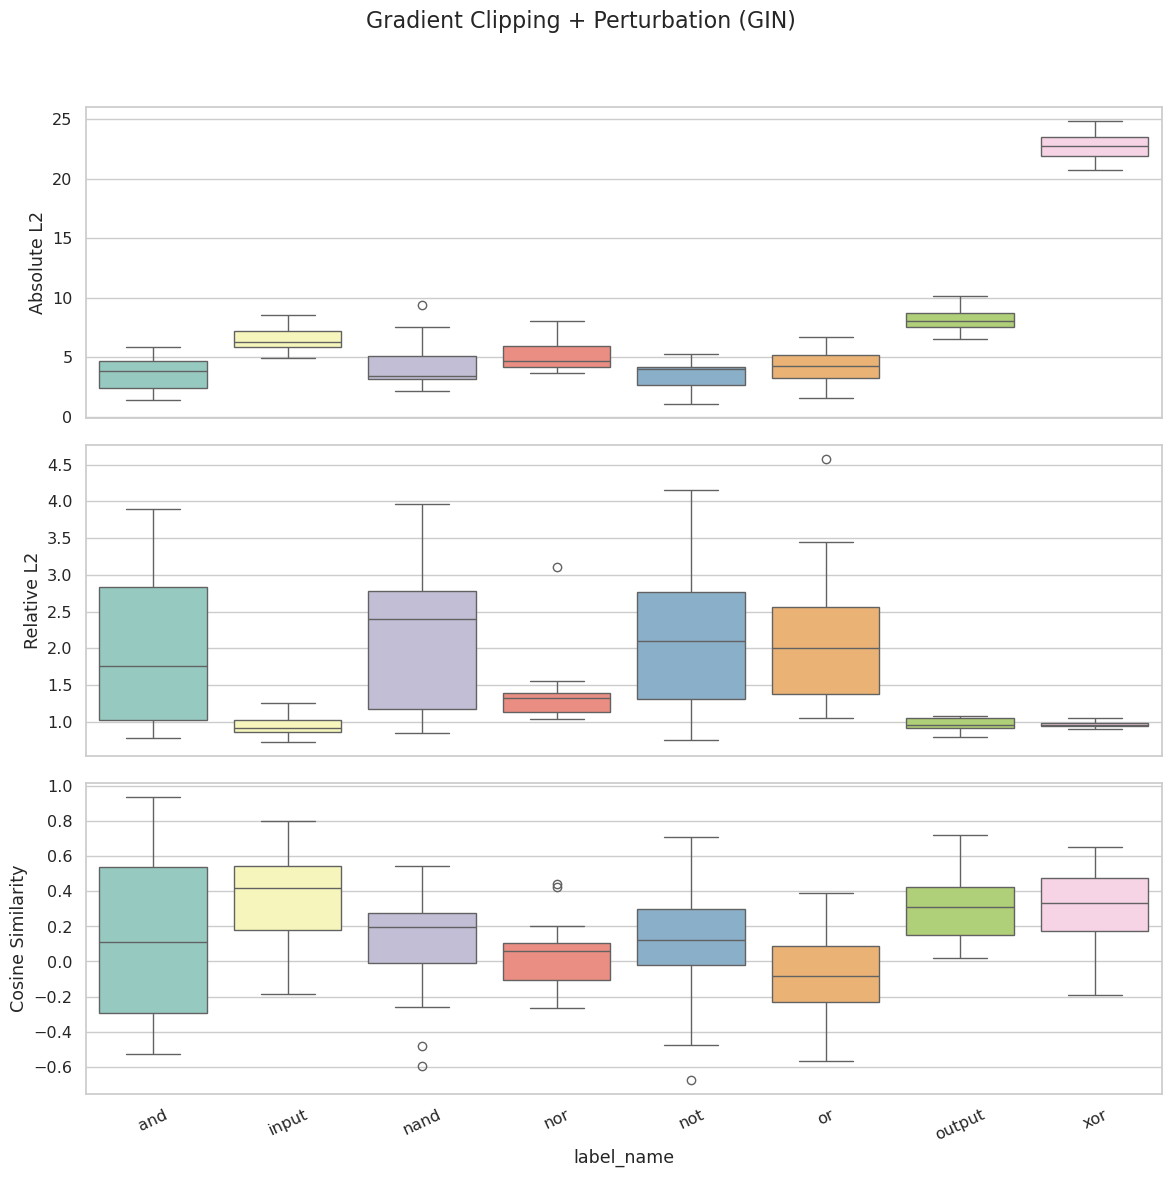


Summary for Gradient Clipping + Perturbation (GIN):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.679172  1.392535    20  1.923186  0.961108    20  0.127625   
input        6.512984  0.904438    20  0.949550  0.131015    20  0.357185   
nand         4.290808  1.850560    20  2.124784  0.872439    20  0.094940   
nor          5.152683  1.314706    20  1.361070  0.437550    20  0.027407   
not          3.467094  1.249567    20  2.078128  0.981129    20  0.130843   
or           4.185825  1.520879    20  2.109949  0.913103    20 -0.068251   
output       8.088015  0.855246    20  0.961938  0.084392    20  0.296549   
xor         22.599734  1.164676    20  0.962473  0.036216    20  0.320257   

                            
                 std count  
label_name                  
and         

/tmp/ipykernel_27022/4189950744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


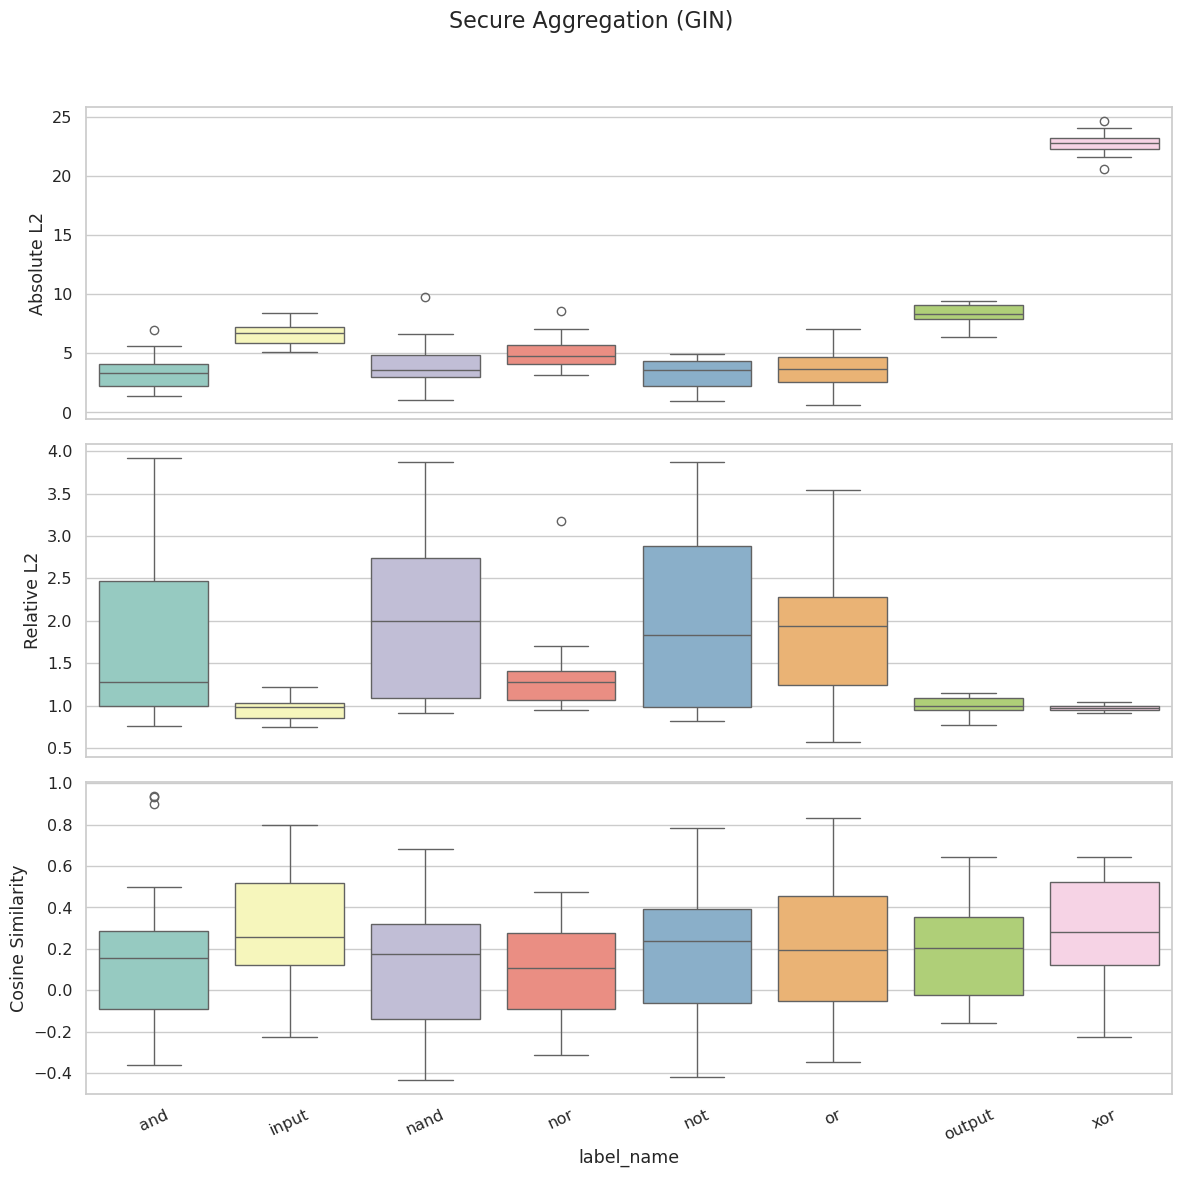


Summary for Secure Aggregation (GIN):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.431047  1.461483    20  1.833926  1.043093    20  0.183013   
input        6.639709  0.885170    20  0.968333  0.130120    20  0.292487   
nand         4.106480  1.892559    20  2.021564  0.922432    20  0.085082   
nor          5.114277  1.371150    20  1.357907  0.478155    20  0.104913   
not          3.271642  1.207192    20  1.985053  0.992269    20  0.196487   
or           3.671906  1.444311    20  1.847120  0.801057    20  0.206634   
output       8.405146  0.772340    20  1.001973  0.101037    20  0.184369   
xor         22.783293  0.910859    20  0.970754  0.035516    20  0.275003   

                            
                 std count  
label_name                  
and         0.390542    20

/tmp/ipykernel_27022/4189950744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


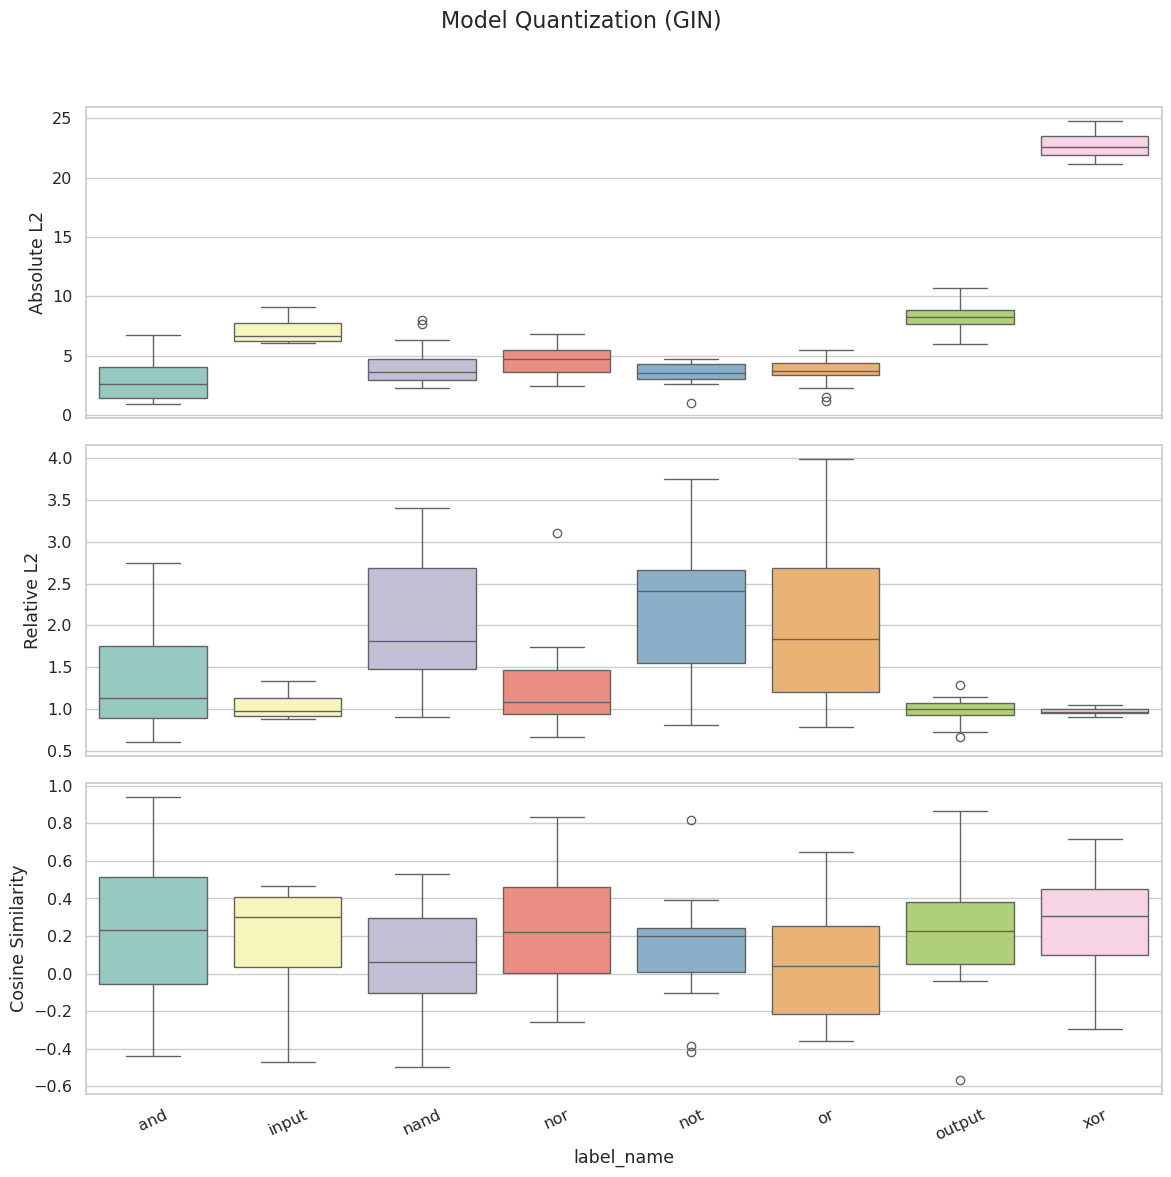


Summary for Model Quantization (GIN):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          2.931888  1.634484    20  1.385661  0.658904    20  0.228617   
input        7.004375  0.879659    20  1.021159  0.126723    20  0.197161   
nand         4.179524  1.638678    20  2.032663  0.735369    20  0.060939   
nor          4.548060  1.176751    20  1.234831  0.529210    20  0.246962   
not          3.540512  0.853190    20  2.143369  0.803732    20  0.137760   
or           3.731982  1.142286    20  1.946100  0.914308    20  0.046571   
output       8.250910  1.207629    20  0.983464  0.145956    20  0.234964   
xor         22.775911  1.087186    20  0.970203  0.037110    20  0.270143   

                            
                 std count  
label_name                  
and         0.431280    20

/tmp/ipykernel_27022/4189950744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
/tmp/ipykernel_27022/4189950744.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")


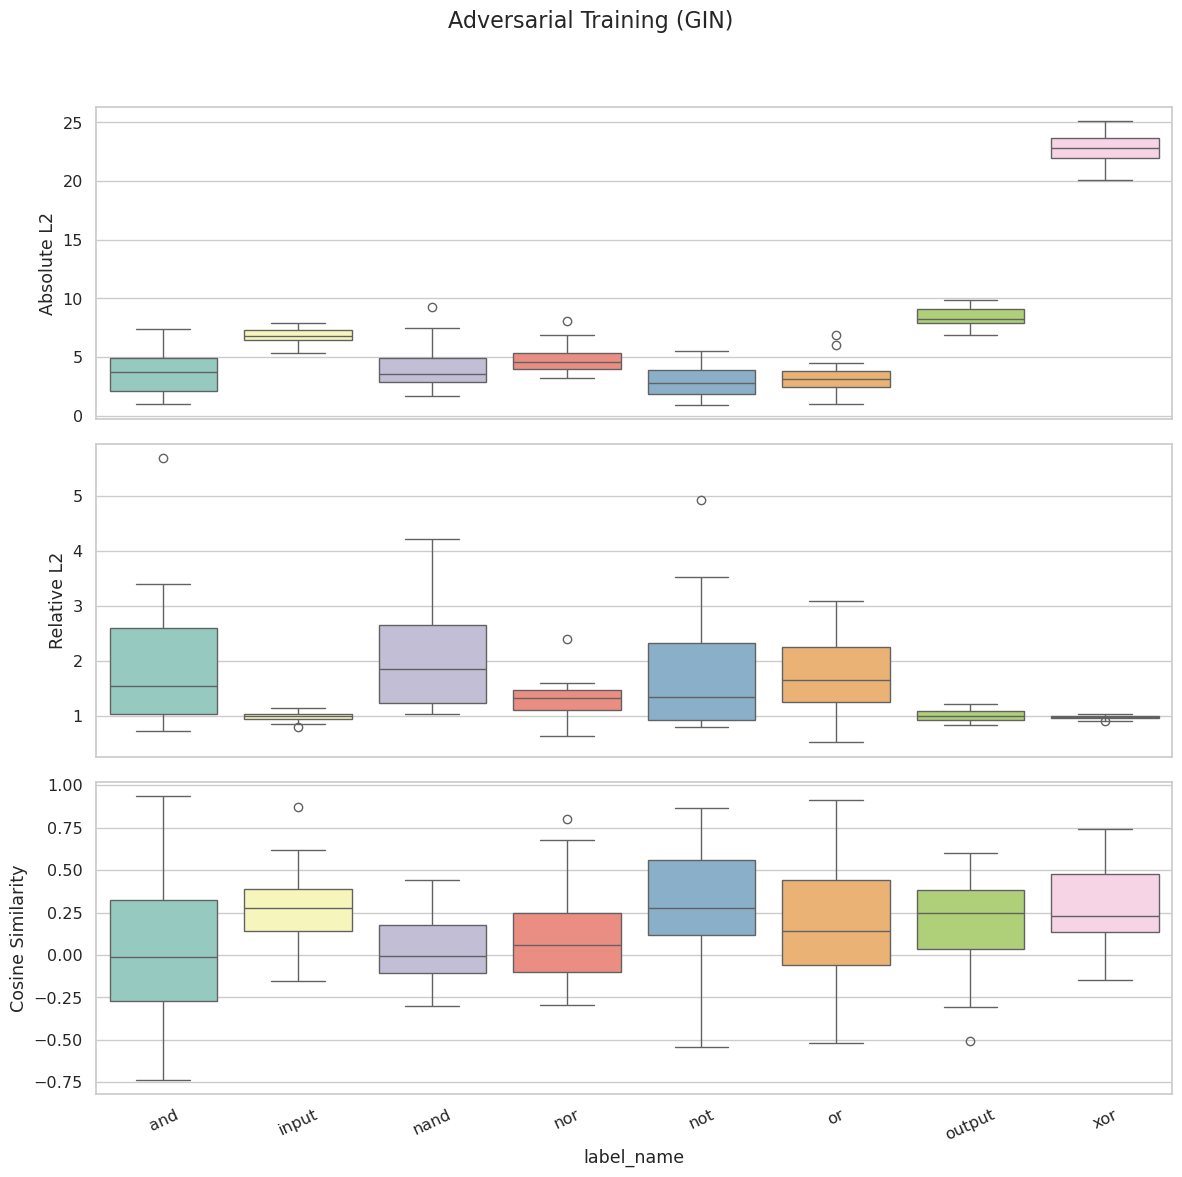


Summary for Adversarial Training (GIN):
               abs_l2                    rel_l2                   cos_sim  \
                 mean       std count      mean       std count      mean   
label_name                                                                  
and          3.790752  1.931872    20  1.952323  1.250289    20  0.099843   
input        6.755628  0.659068    20  0.984796  0.092981    20  0.282706   
nand         4.150034  1.868936    20  2.021230  0.909389    20  0.044049   
nor          4.879280  1.258699    20  1.295613  0.365262    20  0.121601   
not          2.923334  1.356300    20  1.752905  1.083761    20  0.281516   
or           3.266923  1.410351    20  1.650091  0.688505    20  0.187455   
output       8.412121  0.825748    20  1.002404  0.103959    20  0.170069   
xor         22.816784  1.424628    20  0.971083  0.034604    20  0.287667   

                            
                 std count  
label_name                  
and         0.511744    

In [9]:
# ==================== CELL 8: Plotting all GIN results ====================
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, os

sns.set(style="whitegrid", font_scale=1.05)

files = {
    "Differential Privacy": "results_gin_dp.csv",
    "Gradient Clipping + Perturbation": "results_gin_gradclip_perturb.csv",
    "Secure Aggregation": "results_gin_secureagg.csv",
    "Model Quantization": "results_gin_quant.csv",
    "Adversarial Training": "results_gin_advtrain.csv"
}

for pretty_name, fname in files.items():
    if not os.path.exists(fname):
        print(f"Warning: {fname} not found  skipping {pretty_name}")
        continue
    df = pd.read_csv(fname)
    if df.empty:
        print(f"{fname} is empty  skip")
        continue

    order = sorted(df["label"].unique())
    label_order = [df[df["label"]==l]["label_name"].iloc[0] for l in order]

    fig, axs = plt.subplots(3,1, figsize=(12,12), sharex=True)
    fig.suptitle(f"{pretty_name} (GIN)", fontsize=16)

    sns.boxplot(x="label_name", y="abs_l2", data=df, order=label_order, ax=axs[0], palette="Set3")
    axs[0].set_ylabel("Absolute L2"); axs[0].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="rel_l2", data=df, order=label_order, ax=axs[1], palette="Set3")
    axs[1].set_ylabel("Relative L2"); axs[1].tick_params(axis="x", rotation=25)

    sns.boxplot(x="label_name", y="cos_sim", data=df, order=label_order, ax=axs[2], palette="Set3")
    axs[2].set_ylabel("Cosine Similarity"); axs[2].tick_params(axis="x", rotation=25)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    print(f"\nSummary for {pretty_name} (GIN):")
    print(df.groupby("label_name")[["abs_l2","rel_l2","cos_sim"]].agg(["mean","std","count"]))
